<a href="https://colab.research.google.com/github/derialri/KELOMPOK1_PROJECT_BIG-DATA/blob/main/Kelompok1_Dataset_US_Domestic_Flights_2015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Dataset US Domestic Flights 2015
## ETL, EDA, dan Pembuktian 3V Big Data

| | |
|---|---|
| **Dataset** | US Domestic Flights 2015 |
| **Sumber** | Kaggle — Bureau of Transportation Statistics |
| **Jumlah Data** | ~5.819.079 baris × 31 kolom |
| **Ukuran File** | ±565 MB |
| **Tahun Data** | 2015 |



## 0. Setup & Instalasi Library

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2196F3','#FF9800','#4CAF50','#F44336','#9C27B0','#00BCD4','#FF5722']

print("Library berhasil diimport")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


Library berhasil diimport
   pandas  : 2.2.2
   numpy   : 2.0.2


**OTOMATIS UPLOAD DATASET**

In [72]:
# Otomatisasi download dataset dari Google Drive
!gdown --id "1wdXCXLYMw7qigl2zwQc1ac6RnRomKoL3" -O flights.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1wdXCXLYMw7qigl2zwQc1ac6RnRomKoL3
From (redirected): https://drive.google.com/uc?id=1wdXCXLYMw7qigl2zwQc1ac6RnRomKoL3&confirm=t&uuid=8cbfa67e-78af-4cf3-a51d-83cdf300e15d
To: /content/flights.csv
100% 592M/592M [00:04<00:00, 144MB/s]


---
## 1. EXTRACT


In [38]:
try:
  df = pd.read_csv("flights.csv")
  print("Dataset berhasil dimuat")
except  FileNotFoundError:
  print("Dataset tidak ditemukan")

Dataset berhasil dimuat


In [39]:
# Cek ukuran file
file_size_bytes = os.path.getsize("flights.csv")
file_size_mb    = file_size_bytes / (1024 ** 2)
file_size_gb    = file_size_bytes / (1024 ** 3)
print(f"Ukuran file : {file_size_mb:,.1f} MB ({file_size_gb:.3f} GB)")

# Hitung jumlah baris tanpa load penuh (fast count)
with open("flights.csv", 'r') as f:
    total_lines = sum(1 for _ in f) - 1
print(f"Total baris : {total_lines:,}")


Ukuran file : 565.0 MB (0.552 GB)
Total baris : 5,819,079


In [40]:
SAMPLE_SIZE = 300_000

df_raw = pd.read_csv("flights.csv", nrows=SAMPLE_SIZE, low_memory=False)

print(f"Data berhasil di-load ({SAMPLE_SIZE:,} baris sampel)")
print(f"   Shape  : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print()
print("Preview 3 Baris Pertama")
df_raw.head(3)


Data berhasil di-load (300,000 baris sampel)
   Shape  : 300,000 baris × 31 kolom

Preview 3 Baris Pertama


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
print("─── Info Kolom & Tipe Data ───")
print(f"{'Kolom':<25} {'Tipe':<12} {'Non-Null':>10}")
print("─" * 50)
for col in df_raw.columns:
    nn = df_raw[col].notna().sum()
    print(f"{col:<25} {str(df_raw[col].dtype):<12} {nn:>10,}")


─── Info Kolom & Tipe Data ───
Kolom                     Tipe           Non-Null
──────────────────────────────────────────────────
YEAR                      int64           300,000
MONTH                     int64           300,000
DAY                       int64           300,000
DAY_OF_WEEK               int64           300,000
AIRLINE                   object          300,000
FLIGHT_NUMBER             int64           300,000
TAIL_NUMBER               object          299,505
ORIGIN_AIRPORT            object          300,000
DESTINATION_AIRPORT       object          300,000
SCHEDULED_DEPARTURE       int64           300,000
DEPARTURE_TIME            float64         294,561
DEPARTURE_DELAY           float64         294,561
TAXI_OUT                  float64         294,390
WHEELS_OFF                float64         294,390
SCHEDULED_TIME            int64           300,000
ELAPSED_TIME              float64         293,634
AIR_TIME                  float64         293,634
DISTANCE          

---
## 2. TRANSFORM



In [42]:
df = df_raw.copy()
print(f"Working dataframe dibuat: {df.shape}")


Working dataframe dibuat: (300000, 31)


In [43]:
missing = pd.DataFrame({
    'Kolom'          : df.columns,
    'Jumlah Null'    : df.isnull().sum().values,
    'Persentase (%)'  : (df.isnull().sum() / len(df) * 100).round(2).values
}).query('`Jumlah Null` > 0').sort_values('Persentase (%)', ascending=False)

print("─── Kolom dengan Missing Values ───")
print(missing.to_string(index=False))


─── Kolom dengan Missing Values ───
              Kolom  Jumlah Null  Persentase (%)
CANCELLATION_REASON       294314           98.10
   AIR_SYSTEM_DELAY       227757           75.92
     SECURITY_DELAY       227757           75.92
      WEATHER_DELAY       227757           75.92
      AIRLINE_DELAY       227757           75.92
LATE_AIRCRAFT_DELAY       227757           75.92
      ARRIVAL_DELAY         6366            2.12
           AIR_TIME         6366            2.12
       ELAPSED_TIME         6366            2.12
          WHEELS_ON         5870            1.96
            TAXI_IN         5870            1.96
       ARRIVAL_TIME         5870            1.96
         WHEELS_OFF         5610            1.87
           TAXI_OUT         5610            1.87
    DEPARTURE_DELAY         5439            1.81
     DEPARTURE_TIME         5439            1.81
        TAIL_NUMBER          495            0.16


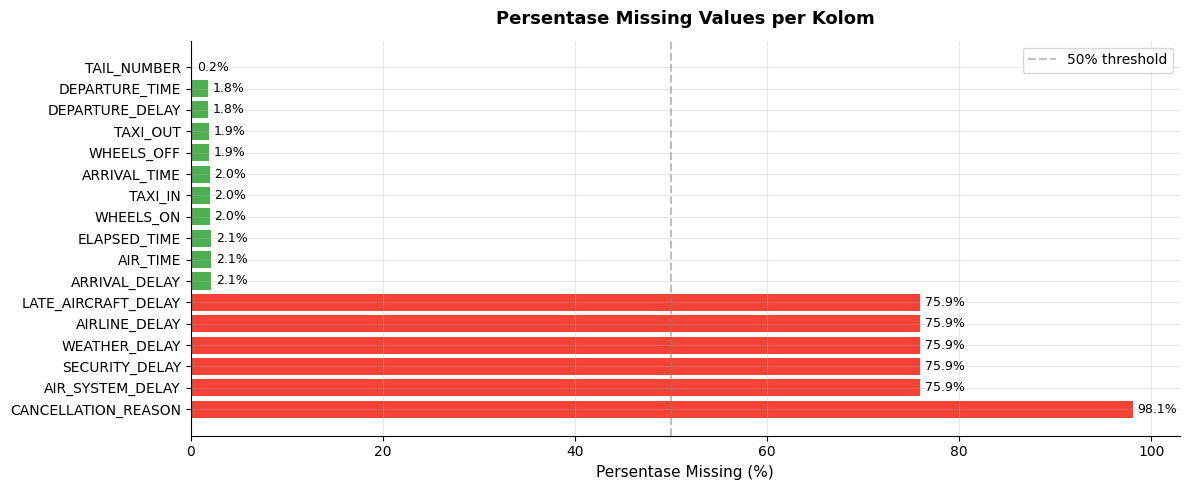

Grafik disimpan: plot_missing_values.png


In [44]:
# ── Visualisasi Missing Values ──
fig, ax = plt.subplots(figsize=(12, 5))
cols_with_null = missing['Kolom'].tolist()
null_pct       = missing['Persentase (%)'].tolist()

bars = ax.barh(cols_with_null, null_pct, color=[
    '#F44336' if p > 50 else '#FF9800' if p > 10 else '#4CAF50'
    for p in null_pct
])
ax.set_xlabel('Persentase Missing (%)', fontsize=11)
ax.set_title('Persentase Missing Values per Kolom', fontsize=13, fontweight='bold', pad=12)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()

# Menaambahkan label nilai
for bar, val in zip(bars, null_pct):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: plot_missing_values.png")


In [45]:
# Penanganan Missing Values
delay_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
              'LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
df[delay_cols] = df[delay_cols].fillna(0)

# CANCELLATION_REASON
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna('N/A')

# Kolom waktu operasional
time_cols = ['DEPARTURE_TIME','DEPARTURE_DELAY','ARRIVAL_TIME','ARRIVAL_DELAY',
             'ELAPSED_TIME','AIR_TIME','TAXI_OUT','TAXI_IN']
before = len(df)
df.dropna(subset=time_cols, inplace=True)
after = len(df)
print(f"aris dihapus karena null di kolom waktu: {before - after:,}")
print(f"Sisa baris: {after:,}")


aris dihapus karena null di kolom waktu: 6,366
Sisa baris: 293,634


In [46]:
# Type Casting
num_cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','DISTANCE','AIR_TIME',
            'ELAPSED_TIME','TAXI_OUT','TAXI_IN'] + delay_cols
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Mapping: kode hari → nama hari
day_map = {1:'Senin',2:'Selasa',3:'Rabu',4:'Kamis',5:'Jumat',6:'Sabtu',7:'Minggu'}
df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_map)

# Mapping: kode bulan → nama bulan
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
             7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}
df['MONTH_NAME'] = df['MONTH'].map(month_map)

# Feature Engineering

# Kategori delay
def categorize_delay(d):
    if d <= 0:    return 'Tepat Waktu / Lebih Awal'
    elif d <= 15: return 'Delay Ringan (1-15 mnt)'
    elif d <= 60: return 'Delay Sedang (16-60 mnt)'
    else:         return 'Delay Parah (>60 mnt)'

df['DELAY_CATEGORY'] = df['ARRIVAL_DELAY'].apply(categorize_delay)

# Flag: apakah penerbangan terlambat tiba? (>15 menit = terlambat resmi FAA)
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

# Total delay breakdown
df['TOTAL_DELAY_CAUSE'] = df[delay_cols].sum(axis=1)

print("Feature Engineering selesai")
print(f"   Kolom baru: DAY_NAME, MONTH_NAME, DELAY_CATEGORY, IS_DELAYED, TOTAL_DELAY_CAUSE")
print(f"   Shape akhir: {df.shape}")


Feature Engineering selesai
   Kolom baru: DAY_NAME, MONTH_NAME, DELAY_CATEGORY, IS_DELAYED, TOTAL_DELAY_CAUSE
   Shape akhir: (293634, 36)


In [47]:
# Cek Duplikasi
dups = df.duplicated().sum()
print(f"Baris duplikat: {dups:,}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"   Duplikat dihapus. Sisa: {len(df):,}")
else:
    print("Tidak ada duplikat")


Baris duplikat: 0
Tidak ada duplikat


In [48]:
# Summary Transformasi
print("=" * 55)
print("        RINGKASAN PROSES TRANSFORM")
print("=" * 55)
print(f"  Baris awal (sampel)    : {len(df_raw):>10,}")
print(f"  Baris setelah cleaning : {len(df):>10,}")
print(f"  Kolom awal             : {df_raw.shape[1]:>10}")
print(f"  Kolom setelah FE       : {df.shape[1]:>10}")
print(f"  Null setelah transform : {df.isnull().sum().sum():>10,}")
print("=" * 55)


        RINGKASAN PROSES TRANSFORM
  Baris awal (sampel)    :    300,000
  Baris setelah cleaning :    293,634
  Kolom awal             :         31
  Kolom setelah FE       :         36
  Null setelah transform :          0


---
## 3. LOAD


In [49]:
# Simpan ke CSV bersih
OUTPUT_PATH = 'flights_cleaned.csv'
df.to_csv(OUTPUT_PATH, index=False)

size_out = os.path.getsize(OUTPUT_PATH) / (1024**2)
print(f"Data bersih berhasil disimpan: {OUTPUT_PATH}")
print(f"   Ukuran file output : {size_out:.1f} MB")
print(f"   Baris tersimpan    : {len(df):,}")
print(f"   Kolom tersimpan    : {df.shape[1]}")


Data bersih berhasil disimpan: flights_cleaned.csv
   Ukuran file output : 49.9 MB
   Baris tersimpan    : 293,634
   Kolom tersimpan    : 36


---
## 4. EDA

### 4.1 Overview Statistik Deskriptif

In [50]:
print("─── Statistik Deskriptif Kolom Numerik Utama ───")
cols_stats = ['DEPARTURE_DELAY','ARRIVAL_DELAY','DISTANCE','AIR_TIME',
              'TAXI_OUT','TAXI_IN'] + delay_cols
df[cols_stats].describe().round(2)


─── Statistik Deskriptif Kolom Numerik Utama ───


,DEPARTURE_DELAY,ARRIVAL_DELAY,DISTANCE,AIR_TIME,TAXI_OUT,TAXI_IN,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,293634.00,293634.00,293634.00,293634.00,293634.00,293634.00,293634.00,293634.00,293634.00,293634.0,293634.00
mean,12.70,9.27,813.08,113.65,16.54,7.72,3.28,0.02,4.45,6.0,0.73
std,39.67,42.66,599.99,72.30,9.57,6.81,13.96,1.03,23.56,23.4,9.82
min,-47.00,-76.00,31.00,8.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00
25%,-4.00,-11.00,370.00,60.00,11.00,4.00,0.00,0.00,0.00,0.0,0.00
50%,-1.00,-2.00,647.00,95.00,14.00,6.00,0.00,0.00,0.00,0.0,0.00
75%,13.00,14.00,1055.00,145.00,19.00,9.00,0.00,0.00,0.00,0.0,0.00
max,1604.00,1593.00,4983.00,676.00,176.00,179.00,824.00,237.00,1593.00,938.0,938.00


### 4.2 Distribusi Delay Keberangkatan & Kedatangan

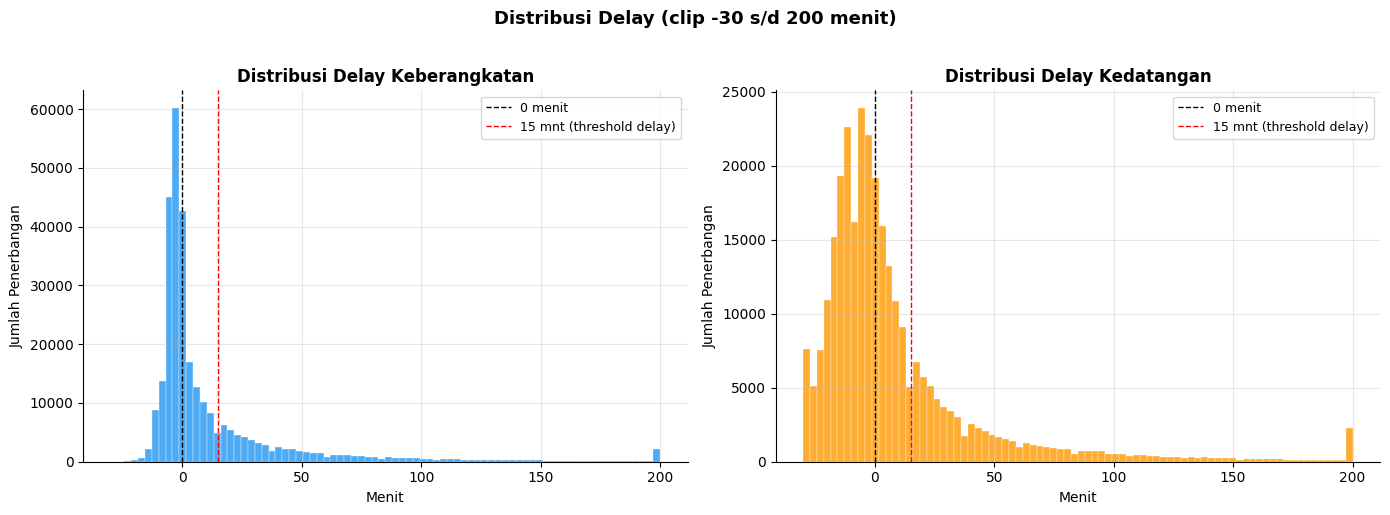

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in zip(
    axes,
    ['DEPARTURE_DELAY', 'ARRIVAL_DELAY'],
    ['#2196F3', '#FF9800'],
    ['Delay Keberangkatan', 'Delay Kedatangan']
):
    data = df[col].clip(-30, 200)
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(x=0,  color='black', linestyle='--', linewidth=1, label='0 menit')
    ax.axvline(x=15, color='red',   linestyle='--', linewidth=1, label='15 mnt (threshold delay)')
    ax.set_title(f'Distribusi {label}', fontweight='bold')
    ax.set_xlabel('Menit')
    ax.set_ylabel('Jumlah Penerbangan')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Delay (clip -30 s/d 200 menit)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_distribusi_delay.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Performa Delay per Maskapai

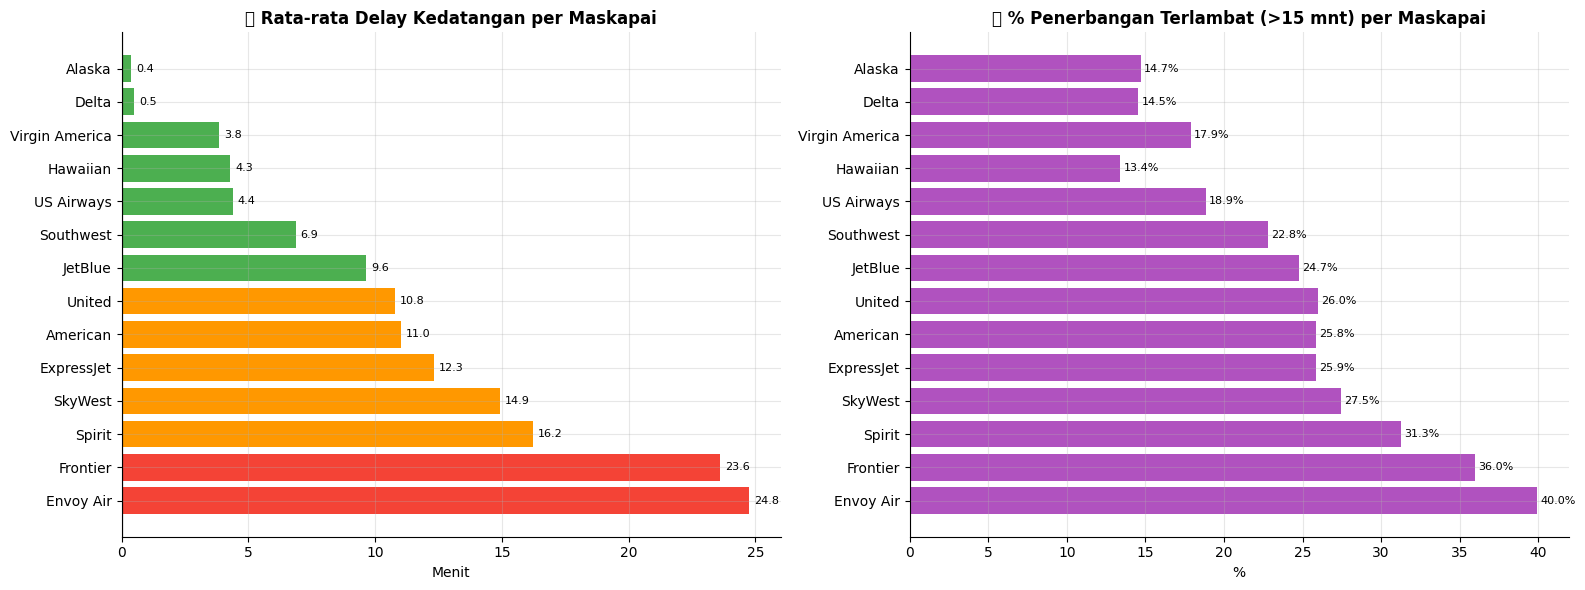

In [52]:
# Peta nama maskapai
airline_names = {
    'UA':'United','AA':'American','US':'US Airways','F9':'Frontier',
    'B6':'JetBlue','OO':'SkyWest','AS':'Alaska','NK':'Spirit',
    'WN':'Southwest','DL':'Delta','EV':'ExpressJet','HA':'Hawaiian',
    'MQ':'Envoy Air','VX':'Virgin America'
}

airline_stats = (
    df.groupby('AIRLINE')
      .agg(
          avg_arr_delay=('ARRIVAL_DELAY','mean'),
          avg_dep_delay=('DEPARTURE_DELAY','mean'),
          pct_delayed   =('IS_DELAYED','mean'),
          total_flights =('FLIGHT_NUMBER','count')
      )
      .reset_index()
      .sort_values('avg_arr_delay', ascending=False)
)
airline_stats['AIRLINE_NAME'] = airline_stats['AIRLINE'].map(airline_names).fillna(airline_stats['AIRLINE'])
airline_stats['pct_delayed'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Avg Arrival Delay
colors = ['#F44336' if v > 20 else '#FF9800' if v > 10 else '#4CAF50'
          for v in airline_stats['avg_arr_delay']]
bars = axes[0].barh(airline_stats['AIRLINE_NAME'], airline_stats['avg_arr_delay'],
                    color=colors)
axes[0].set_title('⏱ Rata-rata Delay Kedatangan per Maskapai', fontweight='bold')
axes[0].set_xlabel('Menit')
axes[0].axvline(x=0, color='black', linewidth=0.8)
for bar, v in zip(bars, airline_stats['avg_arr_delay']):
    axes[0].text(v + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontsize=8)

# Chart 2: % Penerbangan Terlambat
bars2 = axes[1].barh(airline_stats['AIRLINE_NAME'], airline_stats['pct_delayed'],
                     color='#9C27B0', alpha=0.8)
axes[1].set_title('📉 % Penerbangan Terlambat (>15 mnt) per Maskapai', fontweight='bold')
axes[1].set_xlabel('%')
for bar, v in zip(bars2, airline_stats['pct_delayed']):
    axes[1].text(v + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_delay_per_maskapai.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Tren Delay per Bulan

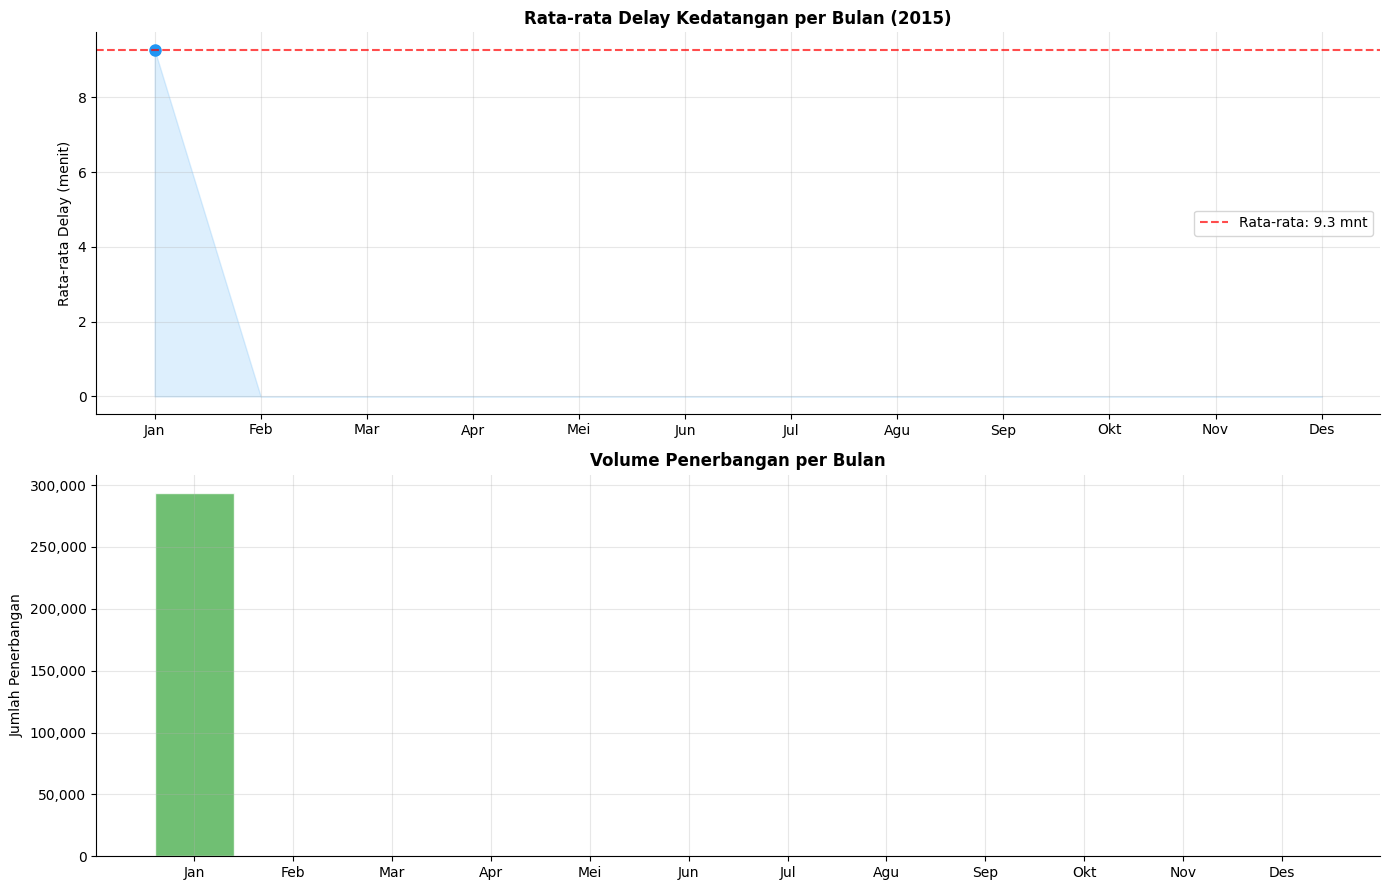

In [53]:
month_order  = list(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

monthly = (
    df.groupby('MONTH')
      .agg(
          avg_delay=('ARRIVAL_DELAY','mean'),
          pct_cancelled=('CANCELLED','mean'),
          total_flights=('FLIGHT_NUMBER','count')
      )
      .reindex(month_order)
)

x = list(range(12))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax1 = axes[0]
ax1.plot(x, monthly['avg_delay'],
         marker='o', color='#2196F3', linewidth=2.5, markersize=8)
ax1.fill_between(x, monthly['avg_delay'].fillna(0),
                 alpha=0.15, color='#2196F3')
ax1.axhline(monthly['avg_delay'].mean(), color='red', linestyle='--', alpha=0.7,
            label=f"Rata-rata: {monthly['avg_delay'].mean():.1f} mnt")
ax1.set_title('Rata-rata Delay Kedatangan per Bulan (2015)', fontweight='bold')
ax1.set_ylabel('Rata-rata Delay (menit)')
ax1.legend()
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels)

ax2 = axes[1]
ax2.bar(x, monthly['total_flights'].fillna(0),
        color='#4CAF50', alpha=0.8, edgecolor='white')
ax2.set_title('Volume Penerbangan per Bulan', fontweight='bold')
ax2.set_ylabel('Jumlah Penerbangan')
ax2.set_xticks(x)
ax2.set_xticklabels(month_labels)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('plot_tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Pola Delay Berdasarkan Hari dalam Seminggu

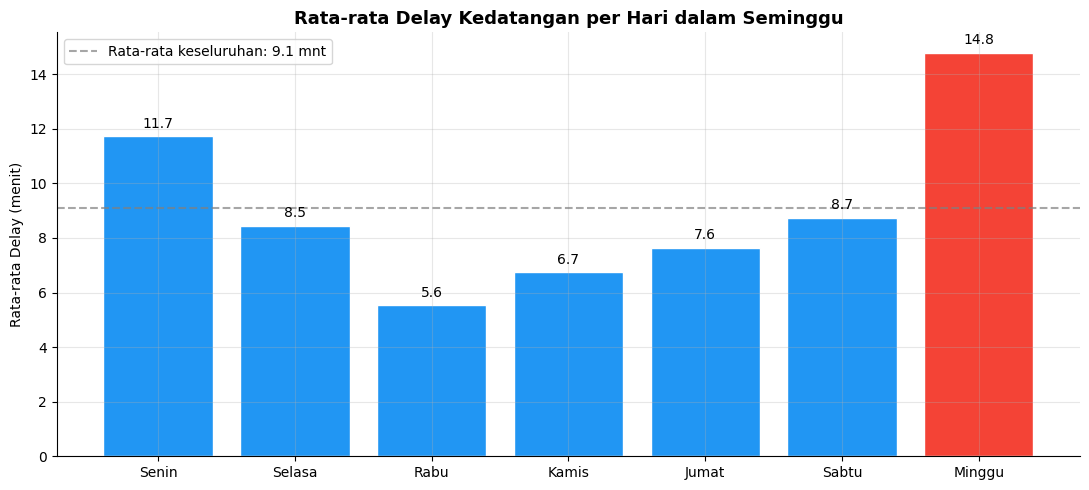

In [54]:
day_order  = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
day_stats  = df.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#F44336' if v == day_stats.max() else '#2196F3' for v in day_stats]
bars = ax.bar(day_stats.index, day_stats.values, color=colors, edgecolor='white')
ax.set_title('Rata-rata Delay Kedatangan per Hari dalam Seminggu', fontsize=13, fontweight='bold')
ax.set_ylabel('Rata-rata Delay (menit)')
ax.axhline(day_stats.mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'Rata-rata keseluruhan: {day_stats.mean():.1f} mnt')
ax.legend()
for bar, v in zip(bars, day_stats):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_delay_hari.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.6 Distribusi Kategori Delay

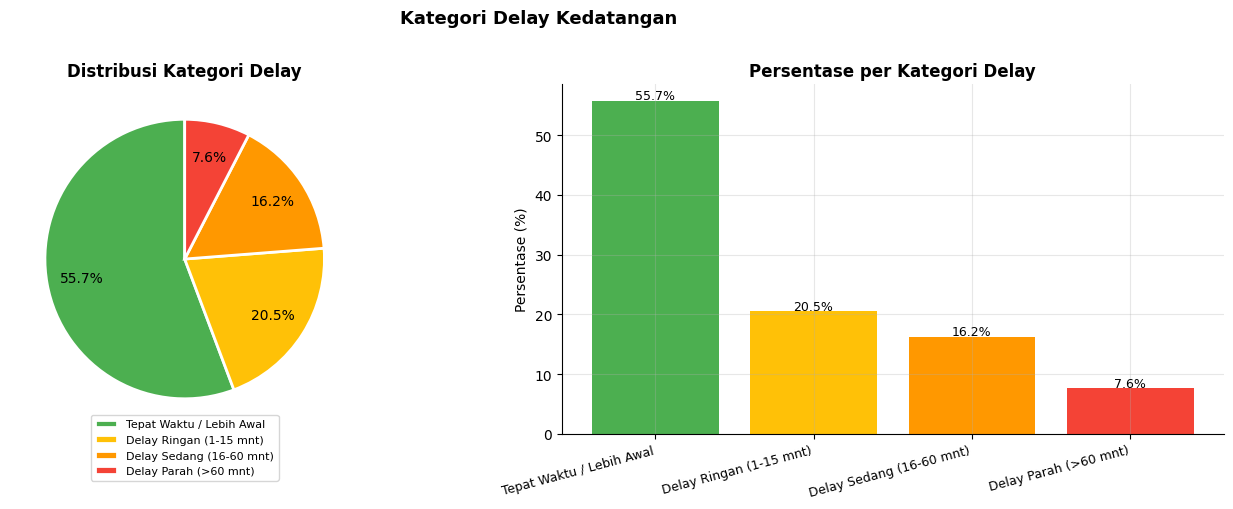

In [55]:
cat_order = ['Tepat Waktu / Lebih Awal','Delay Ringan (1-15 mnt)',
             'Delay Sedang (16-60 mnt)','Delay Parah (>60 mnt)']
cat_counts = df['DELAY_CATEGORY'].value_counts().reindex(cat_order)
cat_pct    = cat_counts / cat_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_pie = ['#4CAF50','#FFC107','#FF9800','#F44336']
wedges, texts, autotexts = axes[0].pie(
    cat_counts, labels=None, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    pctdistance=0.75, wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[0].legend(wedges, cat_order, loc='lower center', fontsize=8,
               bbox_to_anchor=(0.5, -0.15))
axes[0].set_title('Distribusi Kategori Delay', fontweight='bold')

# Bar chart
bars = axes[1].bar(range(len(cat_order)), cat_pct, color=colors_pie)
axes[1].set_xticks(range(len(cat_order)))
axes[1].set_xticklabels(cat_order, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Persentase (%)')
axes[1].set_title('Persentase per Kategori Delay', fontweight='bold')
for bar, v in zip(bars, cat_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Kategori Delay Kedatangan', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_kategori_delay.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.8 Top 10 Bandara Tersibuk & Delay Tertinggi

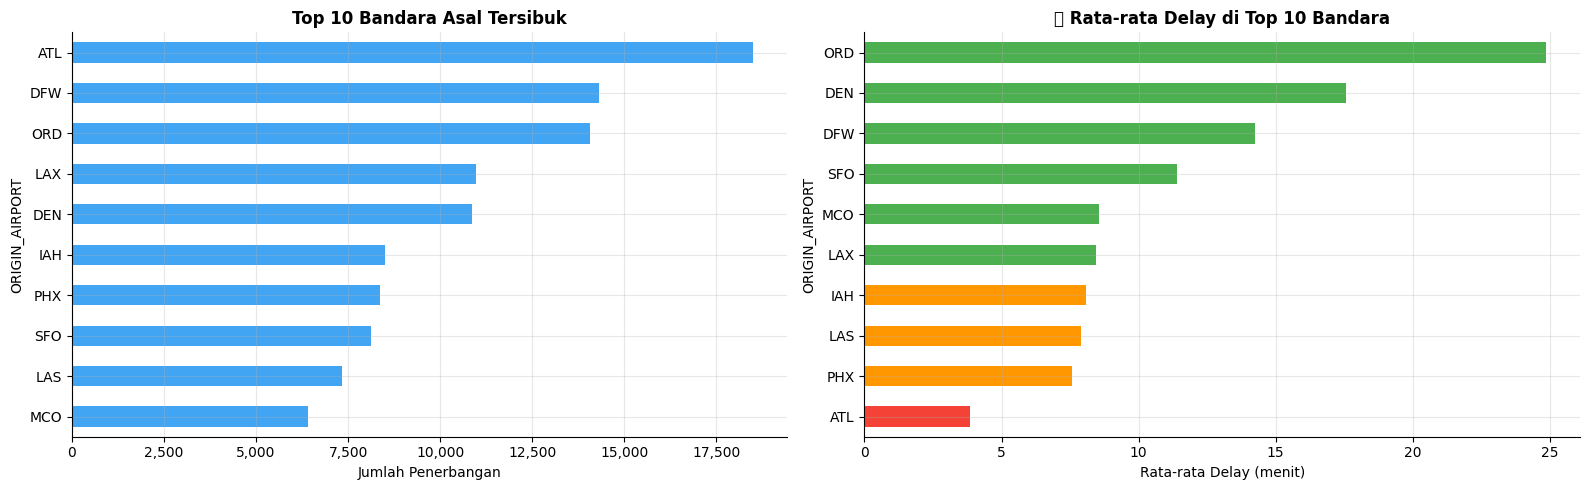

In [56]:
airport_stats = (
    df.groupby('ORIGIN_AIRPORT')
      .agg(total=('FLIGHT_NUMBER','count'), avg_delay=('ARRIVAL_DELAY','mean'))
      .nlargest(10, 'total')
      .sort_values('avg_delay', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume
airport_stats['total'].sort_values().plot(kind='barh', ax=axes[0], color='#2196F3', alpha=0.85)
axes[0].set_title('Top 10 Bandara Asal Tersibuk', fontweight='bold')
axes[0].set_xlabel('Jumlah Penerbangan')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Avg delay
colors_ap = ['#F44336' if v > 20 else '#FF9800' if v > 10 else '#4CAF50'
              for v in airport_stats['avg_delay']]
airport_stats['avg_delay'].sort_values().plot(kind='barh', ax=axes[1], color=colors_ap)
axes[1].set_title('⏱ Rata-rata Delay di Top 10 Bandara', fontweight='bold')
axes[1].set_xlabel('Rata-rata Delay (menit)')

plt.tight_layout()
plt.savefig('plot_top_bandara.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.9 Breakdown Penyebab Delay

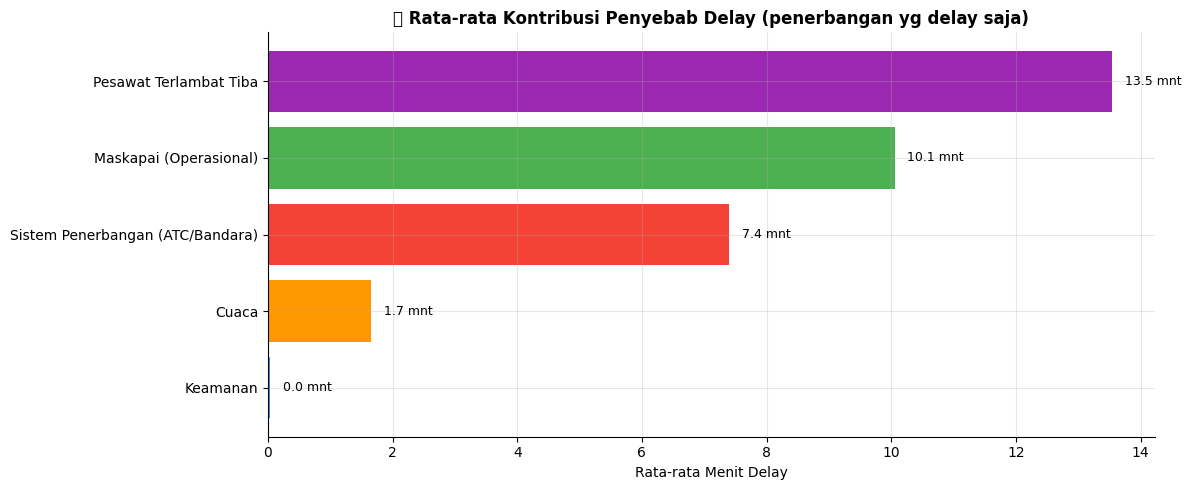

In [57]:
# Hanya penerbangan yang delay
delayed_only = df[df['ARRIVAL_DELAY'] > 0]
cause_means  = delayed_only[delay_cols].mean().sort_values(ascending=True)
cause_labels = {
    'AIR_SYSTEM_DELAY'   : 'Sistem Penerbangan (ATC/Bandara)',
    'AIRLINE_DELAY'       : 'Maskapai (Operasional)',
    'LATE_AIRCRAFT_DELAY' : 'Pesawat Terlambat Tiba',
    'WEATHER_DELAY'       : 'Cuaca',
    'SECURITY_DELAY'      : 'Keamanan'
}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    [cause_labels[c] for c in cause_means.index],
    cause_means.values,
    color=['#2196F3','#FF9800','#F44336','#4CAF50','#9C27B0']
)
ax.set_title('🔍 Rata-rata Kontribusi Penyebab Delay (penerbangan yg delay saja)', fontweight='bold')
ax.set_xlabel('Rata-rata Menit Delay')
for bar, v in zip(bars, cause_means.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f} mnt', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_penyebab_delay.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.10 Heatmap Korelasi Antar Variabel Numerik

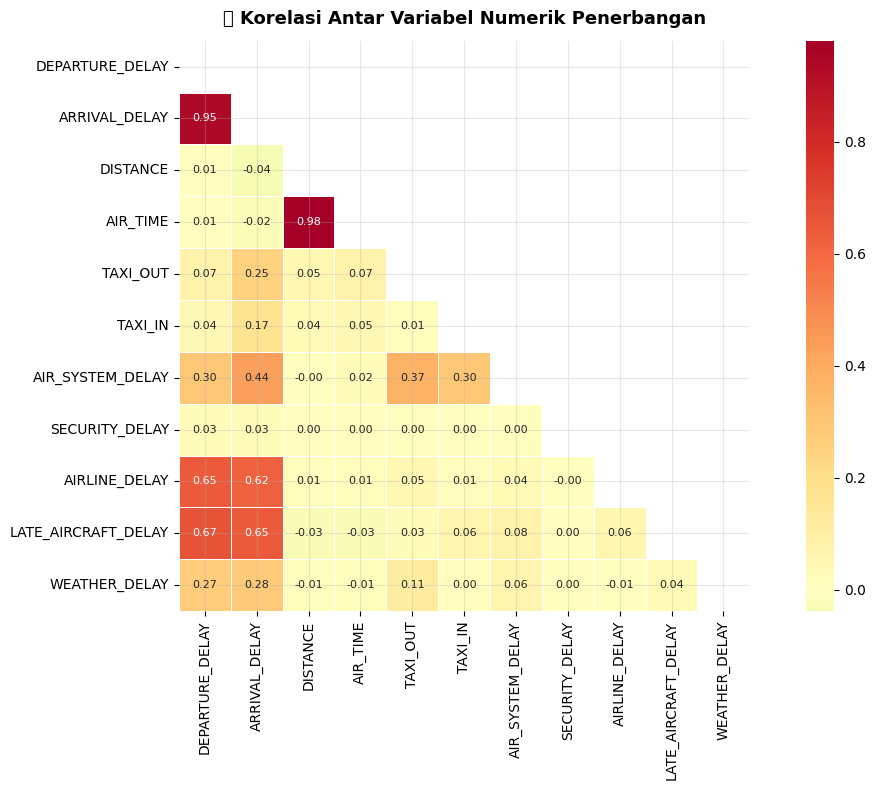

─── Pasangan Korelasi Tinggi (|r| > 0.5) ───
            level_0         level_1  korelasi
           AIR_TIME        DISTANCE  0.980315
      ARRIVAL_DELAY DEPARTURE_DELAY  0.946531
LATE_AIRCRAFT_DELAY DEPARTURE_DELAY  0.671695
      AIRLINE_DELAY DEPARTURE_DELAY  0.649280
LATE_AIRCRAFT_DELAY   ARRIVAL_DELAY  0.647899
      AIRLINE_DELAY   ARRIVAL_DELAY  0.618686


In [58]:
corr_cols = ['DEPARTURE_DELAY','ARRIVAL_DELAY','DISTANCE','AIR_TIME',
             'TAXI_OUT','TAXI_IN'] + delay_cols
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 8})
ax.set_title('🔥 Korelasi Antar Variabel Numerik Penerbangan', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight korelasi tinggi
print("─── Pasangan Korelasi Tinggi (|r| > 0.5) ───")
high_corr = (corr_matrix.abs()
             .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
             .stack()
             .reset_index()
             .rename(columns={0:'korelasi'})
             .query('korelasi > 0.5')
             .sort_values('korelasi', ascending=False))
print(high_corr.to_string(index=False))


---
## 5. Pembuktian 3V Big Data



### 5.1 VOLUME — Skala Data yang Masif

          BUKTI V1: VOLUME

Ukuran file CSV          :      565.0 MB
baris (penerbangan):  5,819,079
Jumlah kolom/atribut     :         31
Cakupan waktu            : 2015 (1 tahun penuh)
Rata-rata per hari       :     15,942 penerbangan
Rata-rata per jam        :        664 penerbangan



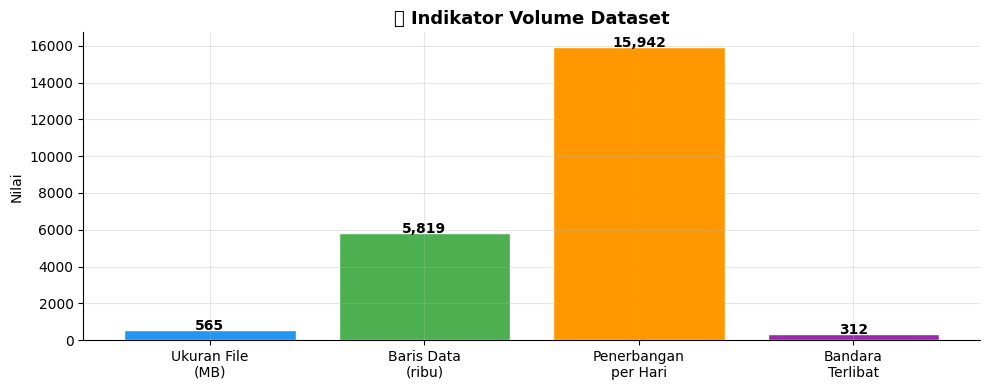

In [59]:
print("=" * 60)
print("          BUKTI V1: VOLUME")
print("=" * 60)
print()
print(f"Ukuran file CSV          : {file_size_mb:>10,.1f} MB")
print(f"baris (penerbangan): {total_lines:>10,}")
print(f"Jumlah kolom/atribut     : {df_raw.shape[1]:>10}")
print(f"Cakupan waktu            : {'2015 (1 tahun penuh)':>20}")
print(f"Rata-rata per hari       : {total_lines//365:>10,} penerbangan")
print(f"Rata-rata per jam        : {total_lines//365//24:>10,} penerbangan")
print()

fig, ax = plt.subplots(figsize=(10, 4))
volume_data = {
    'Ukuran File\n(MB)': file_size_mb,
    'Baris Data\n(ribu)': total_lines / 1000,
    'Penerbangan\nper Hari': total_lines // 365,
    'Bandara\nTerlibat': df_raw['ORIGIN_AIRPORT'].nunique()
}
bars = ax.bar(volume_data.keys(), volume_data.values(),
              color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white')
ax.set_title('📦 Indikator Volume Dataset', fontsize=13, fontweight='bold')
for bar, (k, v) in zip(bars, volume_data.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{v:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Nilai')
plt.tight_layout()
plt.savefig('plot_3v_volume.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 VARIETY — Keberagaman Tipe & Sumber Data

          BUKTI V2: VARIETY

Temporal (Waktu)               (10 kolom)
       - YEAR                           [int64]
       - MONTH                          [int64]
       - DAY                            [int64]
       - DAY_OF_WEEK                    [int64]
       - SCHEDULED_DEPARTURE            [int64]
       - DEPARTURE_TIME                 [float64]
       - SCHEDULED_ARRIVAL              [int64]
       - ARRIVAL_TIME                   [float64]
       - WHEELS_OFF                     [float64]
       - WHEELS_ON                      [float64]

Identitas Penerbangan          (3 kolom)
       - AIRLINE                        [object]
       - FLIGHT_NUMBER                  [int64]
       - TAIL_NUMBER                    [object]

Geografis                      (2 kolom)
       - ORIGIN_AIRPORT                 [object]
       - DESTINATION_AIRPORT            [object]

Operasional                    (6 kolom)
       - TAXI_OUT                       [float64]
       - TAXI_IN     

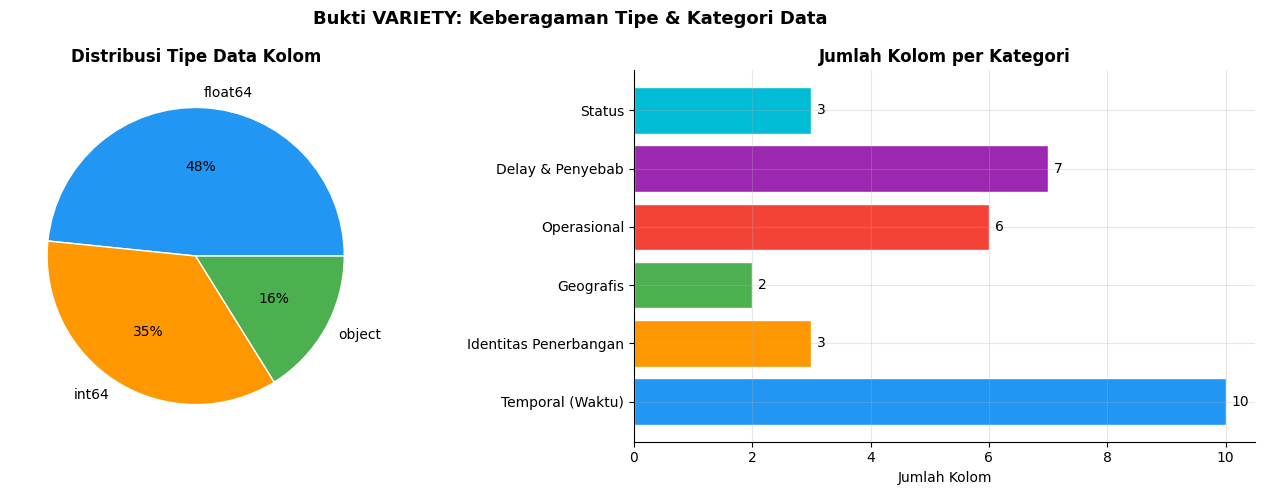

In [60]:
print("=" * 60)
print("          BUKTI V2: VARIETY")
print("=" * 60)

# Kategorisasi kolom
col_categories = {
    'Temporal (Waktu)'   : ['YEAR','MONTH','DAY','DAY_OF_WEEK',
                             'SCHEDULED_DEPARTURE','DEPARTURE_TIME',
                             'SCHEDULED_ARRIVAL','ARRIVAL_TIME',
                             'WHEELS_OFF','WHEELS_ON'],
    'Identitas Penerbangan': ['AIRLINE','FLIGHT_NUMBER','TAIL_NUMBER'],
    'Geografis'          : ['ORIGIN_AIRPORT','DESTINATION_AIRPORT'],
    'Operasional'        : ['TAXI_OUT','TAXI_IN','AIR_TIME',
                             'ELAPSED_TIME','SCHEDULED_TIME','DISTANCE'],
    'Delay & Penyebab'   : ['DEPARTURE_DELAY','ARRIVAL_DELAY',
                             'AIR_SYSTEM_DELAY','SECURITY_DELAY',
                             'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY',
                             'WEATHER_DELAY'],
    'Status'             : ['DIVERTED','CANCELLED','CANCELLATION_REASON']
}

print()
for cat, cols in col_categories.items():
    print(f"{cat:<30} ({len(cols)} kolom)")
    for c in cols:
        dtype = str(df_raw[c].dtype) if c in df_raw.columns else 'derived'
        print(f"       - {c:<30} [{dtype}]")
    print()

# Visualisasi tipe data
dtype_counts = df_raw.dtypes.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie tipe data
axes[0].pie(dtype_counts, labels=[str(x) for x in dtype_counts.index],
            autopct='%1.0f%%', colors=['#2196F3','#FF9800','#4CAF50'],
            wedgeprops={'edgecolor':'white'})
axes[0].set_title('Distribusi Tipe Data Kolom', fontweight='bold')

# Bar kategori kolom
cat_sizes = {k: len(v) for k, v in col_categories.items()}
axes[1].barh(list(cat_sizes.keys()), list(cat_sizes.values()),
             color=PALETTE[:len(cat_sizes)], edgecolor='white')
axes[1].set_title('Jumlah Kolom per Kategori', fontweight='bold')
axes[1].set_xlabel('Jumlah Kolom')
for i, v in enumerate(cat_sizes.values()):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=10)

plt.suptitle('Bukti VARIETY: Keberagaman Tipe & Kategori Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3v_variety.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 VERACITY — Keandalan & Kualitas Data

          BUKTI V3: VERACITY

Missing values sebelum cleaning :  1,492,400 (16.05%)
Missing values setelah cleaning  :          0 (0.00%)

Q1 Arrival Delay   : -11 menit
Q3 Arrival Delay   : 14 menit
IQR                : 25 menit
Outlier terdeteksi : 26,934 baris (9.17%)

Baris dgn selisih dep-arr delay > 5 jam: 0


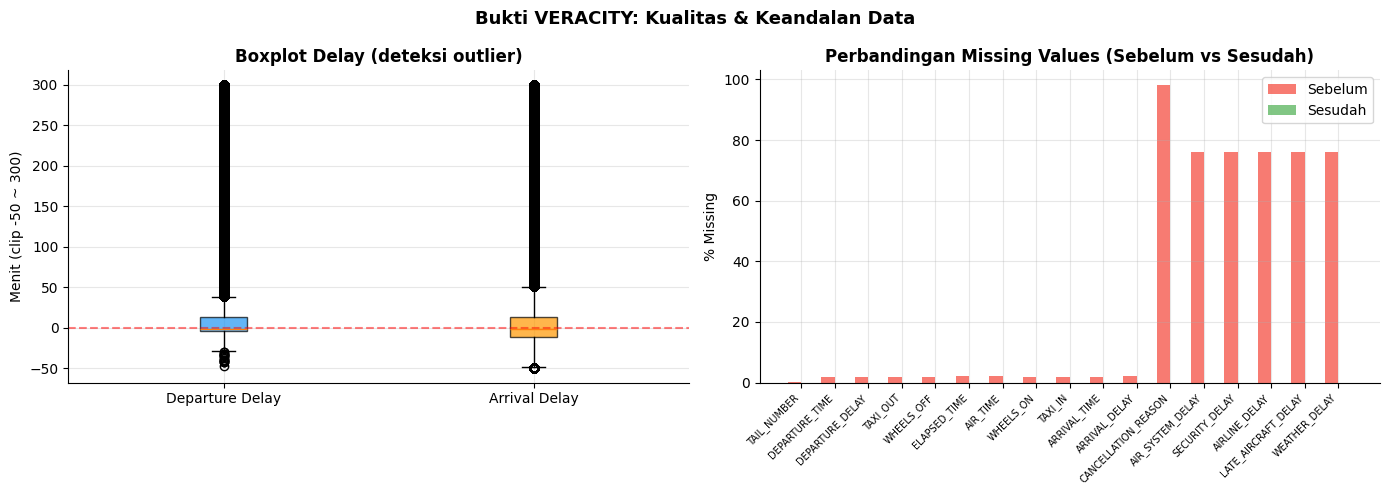

In [61]:
print("=" * 60)
print("          BUKTI V3: VERACITY")
print("=" * 60)

# Null sebelum & sesudah
null_before = df_raw.isnull().sum().sum()
null_after  = df.isnull().sum().sum()
null_before_pct = null_before / (df_raw.shape[0] * df_raw.shape[1]) * 100
null_after_pct  = null_after  / (df.shape[0] * df.shape[1]) * 100

print()
print(f"Missing values sebelum cleaning : {null_before:>10,} ({null_before_pct:.2f}%)")
print(f"Missing values setelah cleaning  : {null_after:>10,} ({null_after_pct:.2f}%)")
print()

# Outlier detection pada arrival delay
Q1 = df['ARRIVAL_DELAY'].quantile(0.25)
Q3 = df['ARRIVAL_DELAY'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask  = (df['ARRIVAL_DELAY'] < Q1 - 1.5*IQR) | (df['ARRIVAL_DELAY'] > Q3 + 1.5*IQR)
outlier_count = outlier_mask.sum()
print(f"Q1 Arrival Delay   : {Q1:.0f} menit")
print(f"Q3 Arrival Delay   : {Q3:.0f} menit")
print(f"IQR                : {IQR:.0f} menit")
print(f"Outlier terdeteksi : {outlier_count:,} baris ({outlier_count/len(df)*100:.2f}%)")
print()

# Uji konsistensi data
inconsistent = df[df['DEPARTURE_DELAY'].notna() & df['ARRIVAL_DELAY'].notna() &
                  (df['ARRIVAL_DELAY'] - df['DEPARTURE_DELAY'] > 300)].shape[0]
print(f"Baris dgn selisih dep-arr delay > 5 jam: {inconsistent:,}")

# Visualisasi veracity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot delay untuk outlier
bp_data = [df['DEPARTURE_DELAY'].clip(-50, 300), df['ARRIVAL_DELAY'].clip(-50, 300)]
bp = axes[0].boxplot(bp_data, labels=['Departure Delay','Arrival Delay'],
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ['#2196F3','#FF9800']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Boxplot Delay (deteksi outlier)', fontweight='bold')
axes[0].set_ylabel('Menit (clip -50 ~ 300)')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Missing value comparison (before vs after)
null_per_col_before = (df_raw.isnull().sum() / len(df_raw) * 100)
null_per_col_after  = (df.isnull().sum() / len(df) * 100)
cols_null = null_per_col_before[null_per_col_before > 0].index

x = range(len(cols_null))
axes[1].bar([i - 0.2 for i in x], null_per_col_before[cols_null],
            width=0.4, label='Sebelum', color='#F44336', alpha=0.7)
axes[1].bar([i + 0.2 for i in x], null_per_col_after.reindex(cols_null).fillna(0),
            width=0.4, label='Sesudah', color='#4CAF50', alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cols_null, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('% Missing')
axes[1].set_title('Perbandingan Missing Values (Sebelum vs Sesudah)', fontweight='bold')
axes[1].legend()

plt.suptitle('Bukti VERACITY: Kualitas & Keandalan Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_3v_veracity.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Analisis Prediktif — Random Forest Classifier

Bagian ini membangun model klasifikasi untuk memprediksi apakah sebuah penerbangan akan terlambat (ARRIVAL_DELAY > 15 menit) menggunakan algoritma **Random Forest**.

In [62]:
# 6.1 Import Library Prediktif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Library prediktif siap")


✅ Library prediktif siap


In [63]:
# 6.2 Persiapan Fitur & Target

# Pastikan IS_DELAYED ada
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

# Encode AIRLINE ke angka
le = LabelEncoder()
df['AIRLINE_ENC'] = le.fit_transform(df['AIRLINE'])

# Fitur dan target
features = ['DEPARTURE_DELAY', 'TAXI_OUT', 'DISTANCE',
            'AIRLINE_ENC', 'DAY_OF_WEEK', 'MONTH']
target   = 'IS_DELAYED'

df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

# Distribusi kelas
dist = y.value_counts(normalize=True) * 100
print("=== Distribusi Kelas Target ===")
print(f"  Tidak Terlambat (0) : {dist[0]:.1f}%")
print(f"  Terlambat       (1) : {dist[1]:.1f}%")
print(f"  Total sampel        : {len(df_model):,}")


=== Distribusi Kelas Target ===
  Tidak Terlambat (0) : 76.2%
  Terlambat       (1) : 23.8%
  Total sampel        : 293,634


In [64]:
# 6.3 Split Data Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data latih : {len(X_train):,} sampel ({len(X_train)/len(X)*100:.0f}%)")
print(f"Data uji   : {len(X_test):,}  sampel ({len(X_test)/len(X)*100:.0f}%)")


Data latih : 234,907 sampel (80%)
Data uji   : 58,727  sampel (20%)


In [65]:
# 6.4 Training Model Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("✅ Model Random Forest selesai dilatih")
print(f"   Jumlah pohon : {rf.n_estimators}")
print(f"   Max depth    : {rf.max_depth}")


✅ Model Random Forest selesai dilatih
   Jumlah pohon : 100
   Max depth    : 10


In [66]:
# 6.5 Evaluasi Model
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=" * 55)
print("        HASIL EVALUASI RANDOM FOREST")
print("=" * 55)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC   : {auc:.4f}  ({auc*100:.2f}%)")
print("=" * 55)
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Tidak Terlambat', 'Terlambat'],
    digits=4
))


        HASIL EVALUASI RANDOM FOREST
  Accuracy  : 0.9360  (93.60%)
  ROC-AUC   : 0.9666  (96.66%)

                 precision    recall  f1-score   support

Tidak Terlambat     0.9428    0.9752    0.9587     44769
      Terlambat     0.9105    0.8101    0.8574     13958

       accuracy                         0.9360     58727
      macro avg     0.9267    0.8927    0.9081     58727
   weighted avg     0.9351    0.9360    0.9346     58727



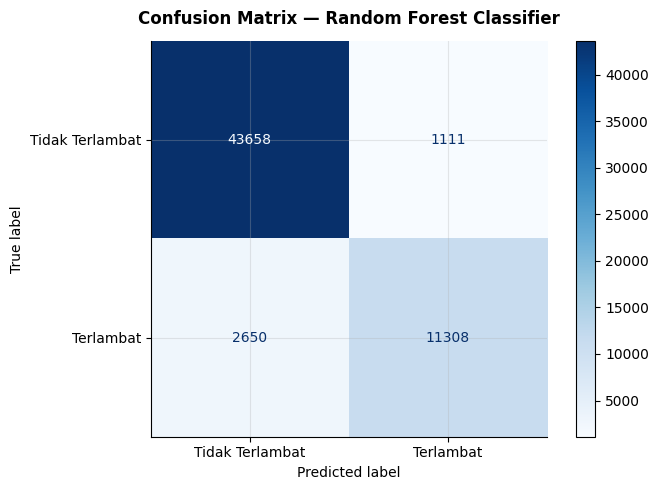

True Negative  (TN) : 43,658  — prediksi benar: tidak terlambat
False Positive (FP) : 1,111  — diprediksi terlambat, aslinya tidak
False Negative (FN) : 2,650  — tidak terdeteksi padahal terlambat
True Positive  (TP) : 11,308  — prediksi benar: terlambat


In [67]:
# 6.6 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Tidak Terlambat', 'Terlambat'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest Classifier',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negative  (TN) : {TN:,}  — prediksi benar: tidak terlambat")
print(f"False Positive (FP) : {FP:,}  — diprediksi terlambat, aslinya tidak")
print(f"False Negative (FN) : {FN:,}  — tidak terdeteksi padahal terlambat")
print(f"True Positive  (TP) : {TP:,}  — prediksi benar: terlambat")


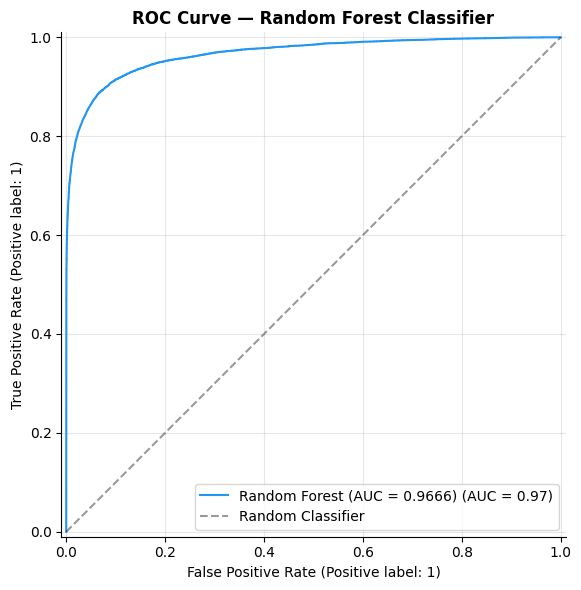

In [68]:
# 6.7 ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f'Random Forest (AUC = {auc:.4f})',
    color='#2196F3', ax=ax
)
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random Classifier')
ax.set_title('ROC Curve — Random Forest Classifier',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


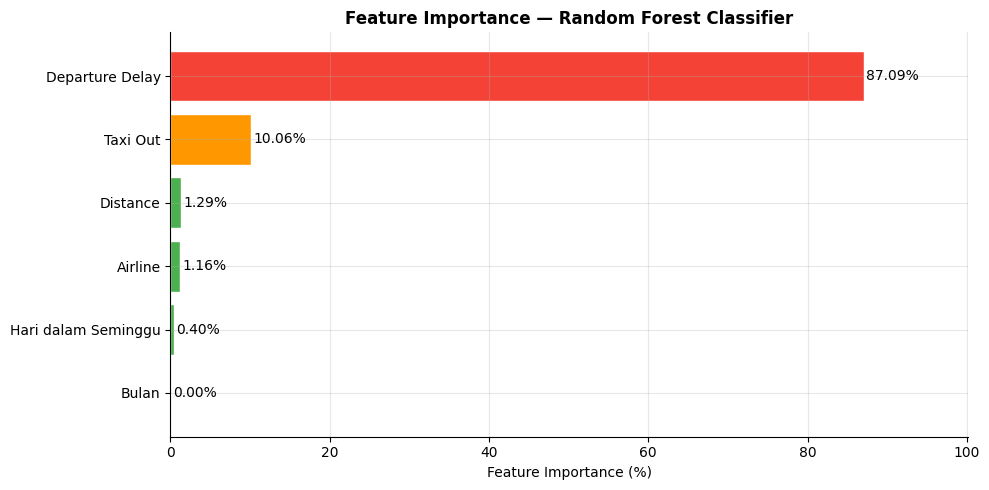

=== Ranking Feature Importance ===
  Departure Delay           : 87.09%
  Taxi Out                  : 10.06%
  Distance                  : 1.29%
  Airline                   : 1.16%
  Hari dalam Seminggu       : 0.40%
  Bulan                     : 0.00%


In [69]:
# 6.8 Feature Importance
label_map = {
    'DEPARTURE_DELAY': 'Departure Delay',
    'TAXI_OUT'       : 'Taxi Out',
    'DISTANCE'       : 'Distance',
    'AIRLINE_ENC'    : 'Airline',
    'DAY_OF_WEEK'    : 'Hari dalam Seminggu',
    'MONTH'          : 'Bulan'
}

fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
fi.index = [label_map[f] for f in fi.index]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if v > 0.5 else '#FF9800' if v > 0.1 else '#4CAF50'
          for v in fi.values]
bars = ax.barh(fi.index, fi.values * 100, color=colors, edgecolor='white')
for bar, v in zip(bars, fi.values * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Feature Importance (%)')
ax.set_title('Feature Importance — Random Forest Classifier',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, max(fi.values * 100) * 1.15)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Ranking Feature Importance ===")
for name, val in fi.sort_values(ascending=False).items():
    print(f"  {name:<25} : {val*100:.2f}%")


In [70]:
# 6.9 Ringkasan Akhir
print("=" * 60)
print("          RINGKASAN ANALISIS PREDIKTIF")
print("=" * 60)
print(f"  Algoritma        : Random Forest Classifier")
print(f"  Jumlah Pohon     : 100  |  Max Depth: 10")
print(f"  Data Latih       : {len(X_train):,} sampel")
print(f"  Data Uji         : {len(X_test):,} sampel")
print(f"  Accuracy         : {acc*100:.2f}%")
print(f"  ROC-AUC          : {auc*100:.2f}%")
fi_sorted = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
top_f = label_map[fi_sorted.index[0]]
top_v = fi_sorted.values[0]*100
print(f"  Fitur Terpenting : {top_f} ({top_v:.2f}%)")
print("=" * 60)


          RINGKASAN ANALISIS PREDIKTIF
  Algoritma        : Random Forest Classifier
  Jumlah Pohon     : 100  |  Max Depth: 10
  Data Latih       : 234,907 sampel
  Data Uji         : 58,727 sampel
  Accuracy         : 93.60%
  ROC-AUC          : 96.66%
  Fitur Terpenting : Departure Delay (87.09%)
